# Data Visualizations

In [1]:
# import packages 
import numpy as np
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib.dates as mdates
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pywaffle import Waffle
from matplotlib.ticker import FuncFormatter

In [2]:
# colors 

'#f5f0e8'   # body-bg, hero bg, conclusion text, back-btn hover area
'#1a1a1a'   # body-color, hero h1, narrative-block text, conclusion bg, picker-btn active border
'#320b8d'   # link-color, kicker, artist-a accent, border-left on narrative-block, back-btn text
'#06395b'   # artist-b accent
'#4f0335'   # artist-c accent
'#252525'   # conclusion type-card background

color1 = ['#320b8d', '#6b46c8', "#cab6fd", 'rgba(50, 11, 141, 0.3)', 'rgba(107, 70, 200, 0.3)' ]
color2 = ['#06395b', "#458dbd", "#adddfc", 'rgba(6, 57, 91, 0.3)', 'rgba(69, 141, 189, 0.3)' ]
color3 = ['#4f0335', '#882a9d', '#e4d1ee', 'rgba(79, 3, 52, 0.3)', 'rgba(136, 42, 157, 0.3)' ]
color4 = ['#6b2d0f', '#bd6220', "#f4c7a7", 'rgba(107, 45, 15, 0.3)', 'rgba(189, 98, 32, 0.3)' ]
color5 = ['#1a5c3a', "#4f916f", "#b4d9c6", 'rgba(79, 145, 111, 0.3)', 'rgba(180, 217, 198, 0.3)' ]

In [3]:
# theme 
sns.set_theme(
    style="whitegrid",
    rc={
        "figure.facecolor": "none",
        "axes.facecolor": "none",
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 20
    }
)

font_manager.fontManager.addfont("PlayfairDisplay-VariableFont_wght.ttf")
plt.rcParams["font.family"] = "Playfair Display"

In [64]:
# load data 
df = pd.read_csv("../data/clean_hot100_history.csv", low_memory=False)

## Number of Songs per Artist

In [65]:
# get unique songs
df_artist = df.copy()
df_artist = df_artist.groupby(by=['title','artist','artist_list']).agg(weeks_in_data = ('chart_date','count'), max_weeks_on_chart = ('weeks_on_chart', 'max')).reset_index()

# explode artist list to make one obs per artist 
df_artist['artist_list'] = df_artist['artist_list'].apply(ast.literal_eval)
df_artist = df_artist.explode('artist_list')

# count number of songs 
num_songs_per_artist = df_artist.groupby(by=['artist_list']).agg(num_songs = ('title','count')).reset_index()
num_songs_per_artist = num_songs_per_artist.sort_values('num_songs', ascending=False)

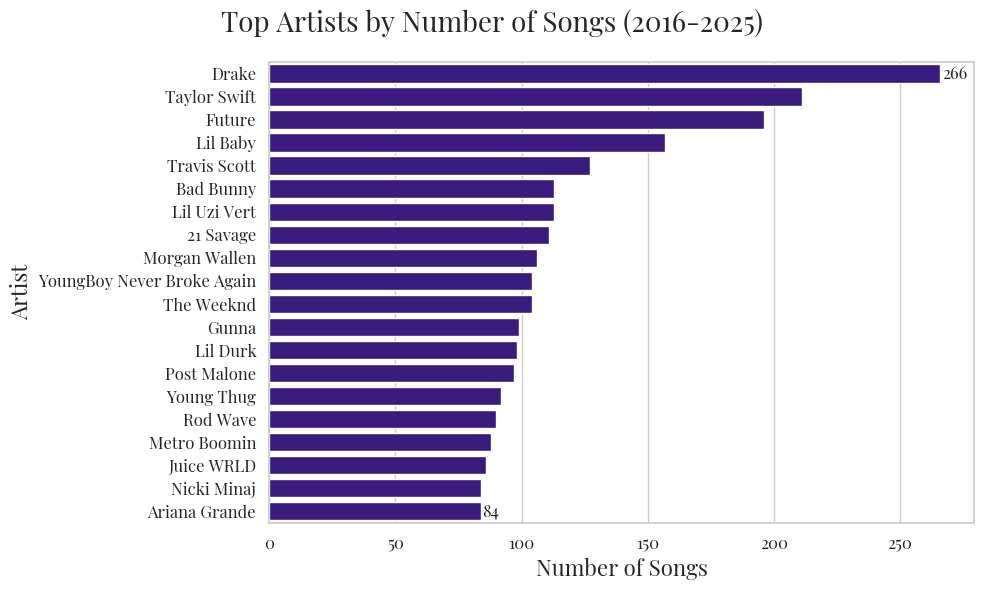

In [ ]:
# keep top N artists
top_n = 20
artist_counts = num_songs_per_artist.head(top_n).reset_index(drop=True)

# plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=artist_counts, x='num_songs', y='artist_list', color='#320b8d')

max_idx = 0
min_idx = 19

for i, row in artist_counts.iterrows():
    if i == max_idx or i == min_idx:
        ax.text(
            row['num_songs'] + 0.5,
            artist_counts.index.get_loc(i),
            str(row['num_songs']),
            va='center'
        )

plt.xlabel('Number of Songs')
plt.ylabel('Artist')
plt.suptitle("Top Artists by Number of Songs (2016-2025)", fontsize=20)
plt.tight_layout()

# save 
plt.savefig('../charts/num_songs_per_artist.svg', format='svg')

plt.show()

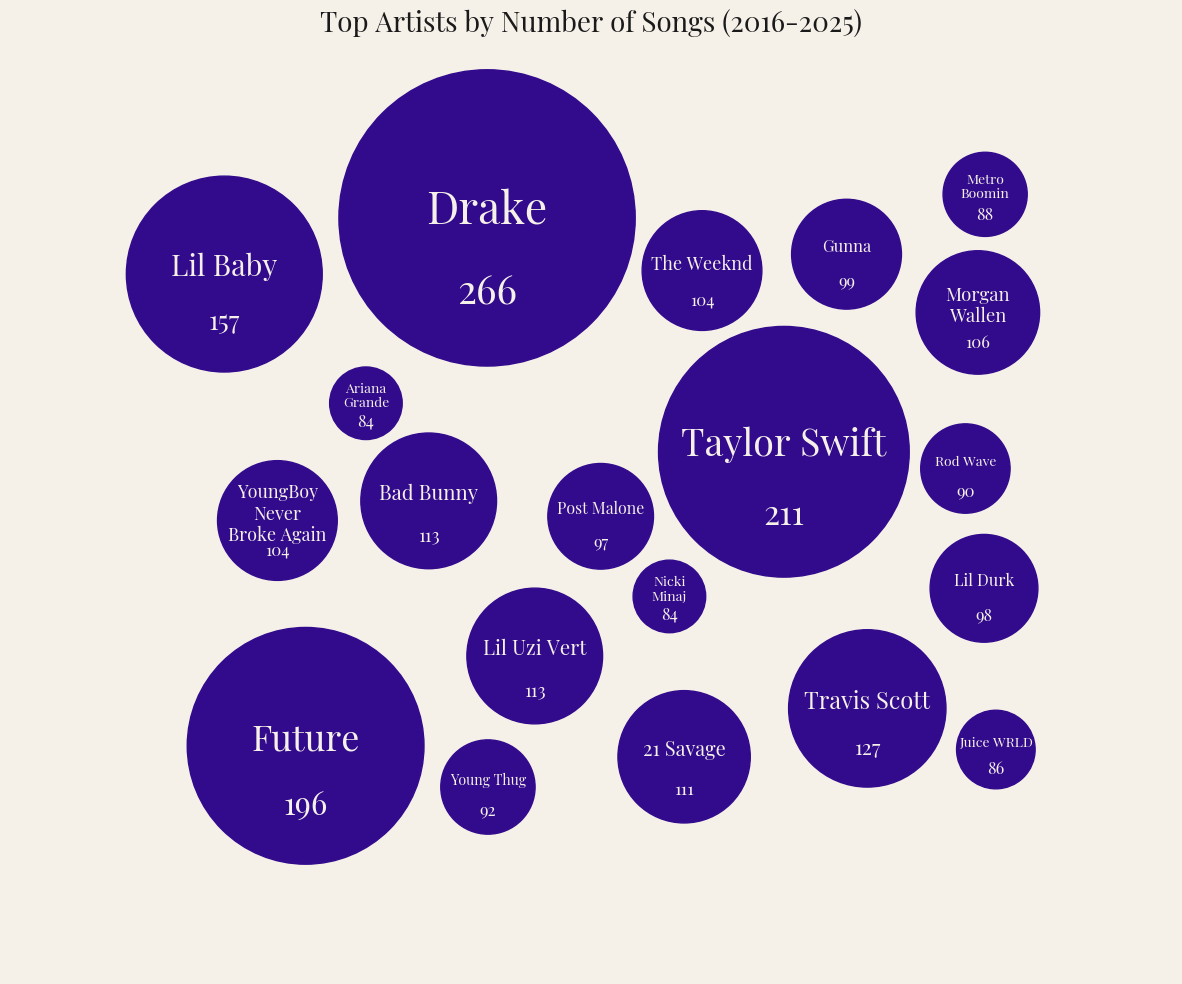

In [100]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.patches import Circle

# keep top N artists
top_n = 20
artist_counts = num_songs_per_artist.head(top_n).reset_index(drop=True)
artist_counts.loc[artist_counts['artist_list']=='YoungBoy Never Broke Again', 'artist_list'] = "YoungBoy\nNever\nBroke Again"
artist_counts.loc[artist_counts['artist_list']=='Ariana Grande', 'artist_list'] = "Ariana\nGrande"
artist_counts.loc[artist_counts['artist_list']=='Nicki Minaj', 'artist_list'] = "Nicki\nMinaj"
artist_counts.loc[artist_counts['artist_list']=='Metro Boomin', 'artist_list'] = "Metro\nBoomin"
artist_counts.loc[artist_counts['artist_list']=='Morgan Wallen', 'artist_list'] = "Morgan\nWallen"

def plot_bubble_cloud(artist_counts, title="Top Artists by Number of Songs (2016-2025)"):
    fig, ax = plt.subplots(figsize=(14, 10))
    fig.patch.set_facecolor('#f5f0e8')
    ax.set_facecolor('#f5f0e8')

    # normalize to area
    min_songs = artist_counts['num_songs'].min()
    max_songs = artist_counts['num_songs'].max()
    min_area, max_area = 0.6, 10   # adjust these to control overall size range

    artist_counts['radius'] = np.sqrt(
        ((artist_counts['num_songs'] - min_songs) / (max_songs - min_songs)
        * (max_area - min_area) + min_area)
        / np.pi
    )

    # place bubbles without overlapping using a simple packing loop
    positions = []
    np.random.seed(42)

    for _, row in artist_counts.iterrows():
        r = row['radius']
        placed = False
        attempts = 0

        while not placed:
            # random candidate position within plot bounds
            x = np.random.uniform(-5, 5)
            y = np.random.uniform(-4, 4)

            # check against all already-placed bubbles
            overlap = False
            for px, py, pr in positions:
                dist = np.sqrt((x - px)**2 + (y - py)**2)
                if dist < r + pr + 0.1:
                    overlap = True
                    break

            if not overlap:
                positions.append((x, y, r))
                placed = True

            attempts += 1
            if attempts > 5000:
                # fallback: place anyway to avoid infinite loop
                positions.append((x, y, r))
                placed = True

    # draw bubbles and labels
    for (x, y, r), (_, row) in zip(positions, artist_counts.iterrows()):
        circle = Circle(
            (x, y), r,
            color='#320b8d',
            alpha=1,
            zorder=2,
        )
        ax.add_patch(circle)

        # artist name
        ax.text(
            x, y + 0.085,
            row['artist_list'],
            ha='center', va='center',
            fontsize=max(10,r*18),
            fontfamily='Playfair Display',
            color='#f5f0e8',
            fontweight='bold',
            zorder=3,
            wrap=True,
        )

        # song count below name
        ax.text(
            x, y - (r * 0.5),
            str(row['num_songs']),
            ha='center', va='center',
            fontsize=max(12,r*16),
            fontfamily='Playfair Display',
            color='#f5f0e8',
            zorder=3,
        )

    # clean up axes
    ax.set_xlim(-7, 7)
    ax.set_ylim(-5.5, 5.5)
    ax.set_aspect('equal')
    ax.axis('off')

    ax.set_title(
        title,
        fontsize=20,
        fontfamily='Playfair Display',
        color='#1a1a1a',
        pad=20,
    )

    plt.tight_layout()
    return fig


fig = plot_bubble_cloud(artist_counts)
plt.savefig('../charts/num_songs_per_artist.svg', format='svg', bbox_inches='tight')
plt.show()

## Max Number of Weeks on Chart per Song

In [7]:
# get unique songs
df_songs = df.copy()
df_songs = df_songs.groupby(by=['title','artist']).agg(weeks_in_data = ('chart_date','count'), max_weeks_on_chart = ('weeks_on_chart', 'max')).reset_index()
num_weeks_per_song = df_songs.sort_values(by=['weeks_in_data'], ascending=False)

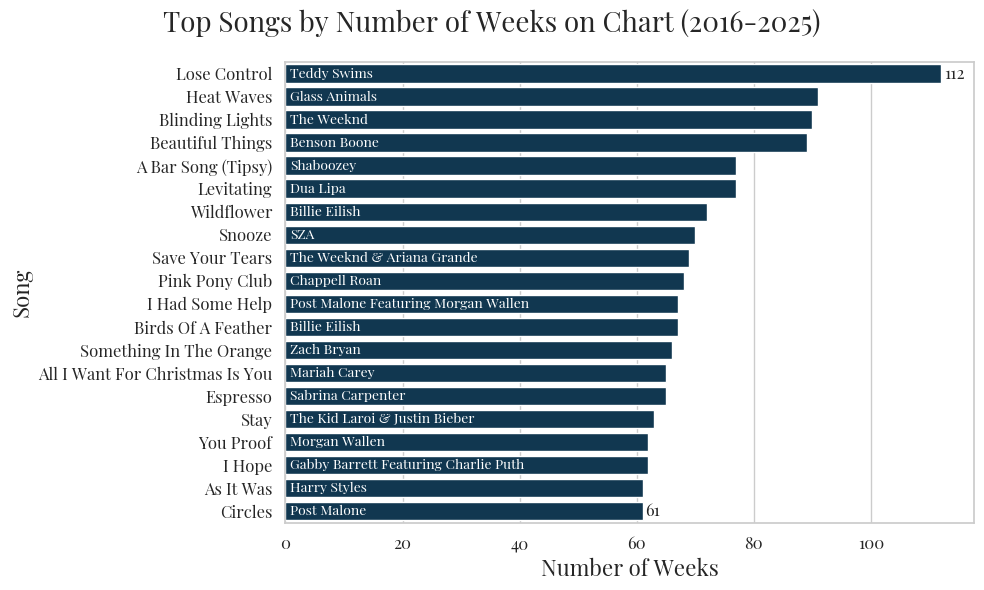

In [8]:
# keep top N songs
top_n = 20
song_counts = num_weeks_per_song.head(top_n).reset_index(drop=True)

# plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=song_counts, x='weeks_in_data', y='title', color='#06395b')

max_idx = 0
min_idx = 19

for i, row in song_counts.iterrows():
    ax.text(
        0.75,
        song_counts.index.get_loc(i),
        str(row['artist']),
        va='center',
        color='white',
        size=10
    )
    if i == max_idx or i == min_idx:
        ax.text(
            row['weeks_in_data'] + 0.5,
            song_counts.index.get_loc(i),
            str(row['weeks_in_data']),
            va='center'
        )

plt.xlabel('Number of Weeks')
plt.ylabel('Song')
plt.suptitle("Top Songs by Number of Weeks on Chart (2016-2025)", fontsize=20)
plt.tight_layout()

# save 
plt.savefig('../charts/num_weeks_per_song.svg', format='svg')

plt.show()

## Fill in weeks off chart with NA

In [185]:
# fill in middle off chart weeks for each song 
df = pd.read_csv("../data/clean_hot100_history.csv", low_memory=False)
songs = df[['title', 'artist', 'artist_list']].drop_duplicates()

In [186]:
def fill_song(group):

    group = group.sort_values("chart_date")

    full_range = pd.date_range(
        start=group["chart_date"].min(),
        end=group["chart_date"].max(),
        freq="W-SAT"
    )
    new_rows = pd.DataFrame(data = {
        'chart_date': full_range,
        'title': group["title"].iloc[0],
        'artist': group["artist"].iloc[0],
        'artist_list': group["artist_list"].iloc[0],
    })
    if new_rows.shape[0] != group.shape[0]:
        new_group = new_rows.merge(group, how='left')
        return new_group 
    else:
        return group

df["chart_date"] = pd.to_datetime(df["chart_date"])
dfs = []
for row in songs.iterrows():
    mask = (df['title']==str(row[1]['title']))&(df['artist']==str(row[1]['artist']))
    group = df.loc[mask]
    song = fill_song(group)
    dfs.append(song)
df_filled = pd.concat(dfs)

In [187]:
df_filled.to_csv('../data/filled_hot100_history.csv', index=False)

## Flash vs Burn categorization

In [ ]:
# import data 
df = pd.read_csv('../data/filled_hot100_history.csv', low_memory=False)

# get rid of songs that only appear for one week 
counts = df.groupby(["title", "artist"])["chart_date"].transform("size")
df = df[counts > 1]

In [351]:
# rise df 

# get new per song columns  
songs = []
for (artist, title, artist_list), group in df.groupby(['artist', 'title', 'artist_list']):
        g = group.sort_values('chart_date').reset_index(drop=True)

        # total number of weeks on chart 
        total_weeks = g['rank'].notna().sum()

        # get rank and week numbers 
        peak_rank = g['rank'].min()           
        debut_rank = g.iloc[0]['rank']
        peak_week = g['rank'].idxmin() 


        # peak_week == 0 means debuted at peak, rise_rate = 0
        if peak_week == 0:
                rise_rate = 0
        else:
                # slope between debut and peak
                rank_improvement = debut_rank - peak_rank   # positive = climbed up
                rise_rate = rank_improvement / peak_week    # positions per week

        songs.append({
                'artist': artist,
                'title': title,
                'artist_list': artist_list,
                'total_weeks': total_weeks,
                'peak_rank': peak_rank,
                'debut_rank': debut_rank,
                'peak_week': peak_week,
                'rise_rate': rise_rate,
        })

rise_df = pd.DataFrame(songs)

In [337]:
rise_df['rise_rate'].describe()

count    3757.000000
mean        3.182902
std         7.093929
min         0.000000
25%         0.000000
50%         0.200000
75%         4.000000
max        98.000000
Name: rise_rate, dtype: float64

In [338]:
rise_df.to_csv('../data/rise_rates.csv', index=False)

In [340]:
# sustained hit 

# get new per song columns  
songs = []
for (artist, title, artist_list), group in df.groupby(['artist', 'title', 'artist_list']):
        g = group.sort_values('chart_date').reset_index(drop=True)

        # total number of weeks on chart 
        total_weeks = g['rank'].notna().sum()

        # get rank and week numbers 
        peak_rank = g['rank'].min()           
        debut_rank = g.iloc[0]['rank']
        end_rank = g.iloc[-1]['rank']
        peak_week = g['rank'].idxmin() 
        post_peak_length = len(g) - 1 - peak_week

        if post_peak_length == 0:
                decay_rate = 0
        else:
                rank_drop  = peak_rank - end_rank
                decay_rate = rank_drop / post_peak_length

        songs.append({
                'artist': artist,
                'title': title,
                'artist_list': artist_list,
                'total_weeks': total_weeks,
                'peak_rank': peak_rank,
                'debut_rank': debut_rank,
                'end_rank': end_rank,
                'peak_week': peak_week,
                'decay_rate': decay_rate,
                'post_peak_length': post_peak_length,
        })

decay_df = pd.DataFrame(songs)

In [342]:
decay_df.decay_rate.describe()

count    3757.000000
mean      -12.145101
std        15.631856
min       -81.000000
25%       -15.000000
50%        -5.250000
75%        -2.166667
max         0.000000
Name: decay_rate, dtype: float64

In [343]:
decay_df.post_peak_length.describe()

count    3757.000000
mean       10.353740
std        22.136454
min         0.000000
25%         2.000000
50%         5.000000
75%        13.000000
max       474.000000
Name: post_peak_length, dtype: float64

In [344]:
decay_df.to_csv('../data/decay_rates.csv', index=False)

rise rate
- look at rank for weeks before it peaked 
- peak rank - debut rank / number of weeks in between those 
- number of ranks risen per week before peak 
- 0.0 = debuted at peak, more positive = more ranks increased per week 

decay rate that performed the 
- look at rank for weeks after it peaked
- end rank - peak rank / number of weeks in between those 
- 0.0 stayed at peak, more negative = higher number of rank places dropped per week 

both basically become the slope from debut to peak and then slope from peak to end 

### Rise vs Decay Plot

In [ ]:
# import data 
rise_df = pd.read_csv("../data/rise_rates.csv", low_memory=False)
decay_df = pd.read_csv("../data/decay_rates.csv", low_memory=False)

both_df = decay_df.merge(rise_df, on=['artist','title', 'total_weeks','peak_rank','debut_rank','peak_week'], how='inner')
both_df['end_week'] = both_df['peak_week'] + both_df['post_peak_length']

both_df['peak_week_1_index'] = both_df['peak_week']+1
both_df['end_week_1_index'] = both_df['end_week']+1

In [ ]:
# create plot

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=both_df['rise_rate'],
    y=both_df['decay_rate'],
    mode='markers',
    marker=dict(
        size=7,
        color=both_df['peak_rank'],
        colorscale=[
            [0.0,  '#320b8d'],
            [1.0,  "#cab6fd"],
        ],
        colorbar=dict(
            title=dict(text="Peak Rank", font=dict(size=11, color="#1a1a1a")),
            tickvals=[1, 25, 50, 75, 100],
            ticktext=["1", "25", "50", "75", "100"],
            tickfont=dict(size=10, color="#1a1a1a"),
            thickness=12,
            len=0.6,
            outlinewidth=0,
        ),
        cmin=1,
        cmax=100,
        line=dict(width=0),
        opacity=0.8,
    ),
    customdata=both_df[['title', 'artist', 'debut_rank', 'peak_rank', 'end_rank', 'peak_week_1_index', 'post_peak_length', 'end_week_1_index']].values,
    hovertemplate=(
        "<b>%{customdata[0]}</b><br>"
        "%{customdata[1]}<br>"
        "<br>"
        "Rise Rate: %{x:.1f}<br>"
        "Decay Rate: %{y:.1f}<br>"
        "<br>"
        "Debut: #%{customdata[2]:.0f}<br>"
        "Peak: #%{customdata[3]:.0f} (week %{customdata[5]:.0f})<br>"
        "End: #%{customdata[4]:.0f} (week %{customdata[7]:.0f})<br>"
        "<extra></extra>"
    ),
))


fig.update_layout(
    title=dict(
        text=f"<b>Rise Rate vs Decay Rate</b>",
        font=dict(family="Playfair Display, serif", size=18, color="#1a1a1a"),
    ),
    plot_bgcolor="#f5f0e8",
    paper_bgcolor="#f5f0e8",
    font=dict(family="Playfair Display, serif", color="#1a1a1a"),
    xaxis=dict(
        title="Rise Rate (positions per week)",
        gridcolor="#d8d2c6",
        linecolor="#1a1a1a",
        zerolinecolor="#d8d2c6",
    ),
    yaxis=dict(
        title="Decay Rate (positions per week)",
        gridcolor="#d8d2c6",
        linecolor="#1a1a1a",
        zerolinecolor="#d8d2c6",
    ),
    hoverlabel=dict(
        bgcolor="#1a1a1a",
        bordercolor="#1a1a1a",
        font=dict(family="Source Sans 3, sans-serif", size=11, color="#f5f0e8"),
    ),
    width=900,
    height=600,
    margin=dict(t=60, r=20, b=60, l=60),
)

In [41]:
fig.write_html(f"../charts/rise_vs_decay.html", include_plotlyjs="cdn", full_html=False)

### Find Artists to Highlight

In [352]:
# find artists that have highest rise rates 

# explode artist list to make one obs per artist 
rise_df['artist_list'] = rise_df['artist_list'].apply(ast.literal_eval)
rise_artist_df = rise_df.explode('artist_list')

# group by artist and find highest average rise rate
artist_rise_mean = rise_artist_df.groupby('artist_list').agg(mean_rise_rate = ('rise_rate','mean'), num_songs = ('artist_list','count'))

artist_rise_mean = artist_rise_mean.sort_values('mean_rise_rate', ascending=False)
artist_rise_mean.loc[artist_rise_mean['num_songs']>=20].head(20)

,mean_rise_rate,num_songs
artist_list,,
Billie Eilish,7.828050,31
Selena Gomez,7.651898,22
Bad Bunny,6.295155,83
Rod Wave,5.434918,32
"Tyler, The Creator",4.984375,32
Nicki Minaj,4.888579,51
A Boogie wit da Hoodie,4.448990,22
YoungBoy Never Broke Again,4.038449,37
DaBaby,3.947214,32


In [355]:
# find artists that have highest rise rates 

# explode artist list to make one obs per artist 
rise_artist_df = rise_df.explode('artist_list')

# remove songs with zero rise rate 
rise_artist_df2 = rise_artist_df.loc[rise_artist_df['rise_rate']!=0]

# group by artist and find highest average rise rate
artist_rise_mean = rise_artist_df2.groupby('artist_list').agg(mean_rise_rate = ('rise_rate','mean'), num_songs = ('artist_list','count'))

artist_rise_mean = artist_rise_mean.sort_values('mean_rise_rate', ascending=False)
artist_rise_mean.loc[artist_rise_mean['num_songs']>=10].head(20)

,mean_rise_rate,num_songs
artist_list,,
Billie Eilish,20.222463,12
Taylor Swift,16.734168,18
Bad Bunny,15.833268,33
Rod Wave,13.378259,13
6ix9ine,12.750000,10
Selena Gomez,11.222784,15
Lil Baby,10.966098,20
Nicki Minaj,10.839893,23
YoungBoy Never Broke Again,9.961508,15


In [356]:
# find artists that have lowest decay rates 

# explode artist list to make one obs per artist 
decay_df['artist_list'] = decay_df['artist_list'].apply(ast.literal_eval)
decay_artist_df = decay_df.explode('artist_list')

# group by artist and find highest average rise rate
artist_decay_mean = decay_artist_df.groupby('artist_list', as_index=False).agg(mean_decay_rate = ('decay_rate','mean'), num_songs = ('artist_list','count'))
artist_decay_mean = artist_decay_mean.sort_values('mean_decay_rate', ascending=False)
artist_decay_mean.loc[artist_decay_mean['num_songs']>=10].head(20)

,artist_list,mean_decay_rate,num_songs
386,Fuerza Regida,-3.058071,14
819,Ozuna,-3.199934,17
961,Shawn Mendes,-3.564372,14
905,Rihanna,-3.780773,14
308,Dua Lipa,-3.883793,20
942,Sam Hunt,-3.930138,10
582,Khalid,-4.093639,23
208,Chris Brown,-4.140305,32
460,J Balvin,-4.236020,16
193,Charlie Puth,-4.273068,10


In [61]:
# find artists that have lowest decay rates 

# explode artist list to make one obs per artist 
# decay_df['artist_list'] = decay_df['artist_list'].apply(ast.literal_eval)
decay_artist_df = decay_df.explode('artist_list')

# group by artist and find highest average rise rate
artist_decay_mean = decay_artist_df.groupby('artist_list', as_index=False).agg(mean_decay_rate = ('decay_rate','mean'), num_songs = ('artist_list','count'))
artist_decay_mean = artist_decay_mean.sort_values('mean_decay_rate', ascending=False)
artist_decay_mean.loc[artist_decay_mean['num_songs']>=20].head(20)

,artist_list,mean_decay_rate,num_songs
308,Dua Lipa,-3.883793,20
582,Khalid,-4.093639,23
208,Chris Brown,-4.140305,32
1066,Thomas Rhett,-5.466105,21
559,Kane Brown,-5.469571,22
836,Peso Pluma,-6.496619,25
495,Jason Aldean,-6.926243,20
563,Karol G,-6.967057,20
955,Selena Gomez,-7.152872,22
295,Doja Cat,-7.576296,24


In [56]:
# songs with lowest decay rates
decay_df2 = decay_df.loc[decay_df['decay_rate']!=0]
decay_df2.sort_values('decay_rate',ascending=False).head(20)

,artist,title,artist_list,total_weeks,peak_rank,debut_rank,end_rank,peak_week,decay_rate,post_peak_length
1135,Fetty Wap,Again,Fetty Wap,9,38.0,45.0,41.0,2,-0.006329,474
783,Dean Martin,Let It Snow! Let It Snow! Let It Snow!,Dean Martin,41,7.0,41.0,8.0,264,-0.009709,103
765,Darlene Love,Christmas (Baby Please Come Home),Darlene Love,31,15.0,50.0,17.0,209,-0.012821,156
121,Andy Williams,It's The Most Wonderful Time Of The Year,Andy Williams,50,5.0,48.0,9.0,208,-0.015385,260
429,Brenda Lee,Rockin' Around The Christmas Tree,Brenda Lee,56,1.0,38.0,3.0,414,-0.018692,107
2332,Michael Buble,It's Beginning To Look A Lot Like Christmas,Michael Buble,29,12.0,39.0,13.0,212,-0.019608,51
1579,Jose Feliciano,Feliz Navidad,Jose Feliciano,41,6.0,44.0,14.0,208,-0.030769,260
3743,d4vd,Romantic Homicide,d4vd,21,33.0,77.0,38.0,4,-0.032258,155
640,Chuck Berry,Run Rudolph Run,Chuck Berry,27,10.0,45.0,19.0,104,-0.034615,260
3347,The Ronettes,Sleigh Ride,The Ronettes,38,8.0,41.0,12.0,261,-0.038095,105


## Per Artist Viz 

In [4]:
# import data
df = pd.read_csv('../data/filled_hot100_history.csv', low_memory=False)

# explode artists
df['artist_list'] = df['artist_list'].apply(ast.literal_eval)
df = df.explode('artist_list')

In [5]:
# filter to specific artist
artists = ['Taylor Swift', 'Bad Bunny', 'Shawn Mendes', 'Luke Combs']
artist = artists[0]
mask = (df['artist_list']==artist)
artist_df = df.loc[mask]

In [6]:
# merge with viral or decay to get song rates 
rise_df = pd.read_csv('../data/rise_rates.csv', low_memory=False)
rise_df['artist_list'] = rise_df['artist_list'].apply(ast.literal_eval)
rise_artist_df = rise_df.explode('artist_list')
heatmap_df = artist_df.merge(rise_artist_df, on=['title','artist_list'], how='inner')
heatmap_df = heatmap_df.sort_values('rise_rate', ascending=False)

In [7]:
# get both rise and decay for violin plot 
decay_df = pd.read_csv('../data/decay_rates.csv', low_memory=False)
decay_df['artist_list'] = decay_df['artist_list'].apply(ast.literal_eval)
decay_artist_df = decay_df.explode('artist_list')
both_df = decay_df.merge(rise_df, on=['artist','title', 'total_weeks','peak_rank','debut_rank','peak_week'], how='outer')
both_df['artist_list'] = both_df['artist_list_x']
both_df.drop(columns=['artist_list_x','artist_list_y'], inplace=True)
both_df = both_df.explode('artist_list')
violin_df = both_df.loc[both_df['artist_list']==artist]
violin_df.head()

,artist,title,total_weeks,peak_rank,debut_rank,end_rank,peak_week,decay_rate,post_peak_length,rise_rate,artist_list
1064,Ed Sheeran Featuring Taylor Swift,The Joker And The Queen,3,21.0,21.0,75.0,0,-27.000000,2,0.0,Taylor Swift
1284,Gracie Abrams Featuring Taylor Swift,Us.,2,36.0,36.0,74.0,0,-38.000000,1,0.0,Taylor Swift
3131,Sugarland Featuring Taylor Swift,Babe,2,72.0,72.0,95.0,0,-3.285714,7,0.0,Taylor Swift
3172,Taylor Swift,'Tis The Damn Season,2,39.0,39.0,91.0,0,-52.000000,1,0.0,Taylor Swift
3173,Taylor Swift,...Ready For It?,19,4.0,4.0,96.0,0,-5.111111,18,0.0,Taylor Swift


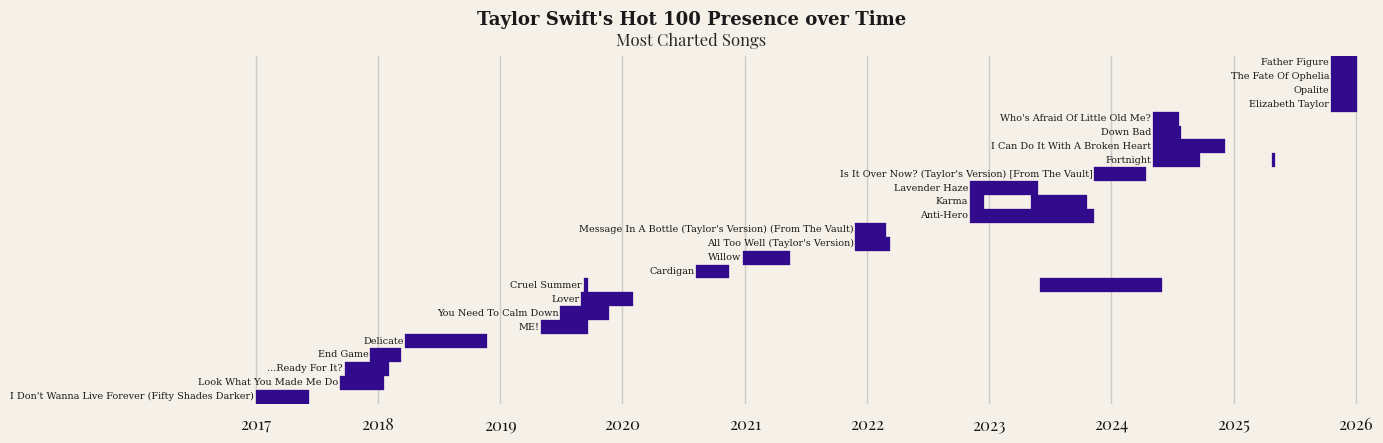

In [15]:
# timeline strip function 

def plot_timeline_strip(artist_df, artist_name, colors, n=25, figsize=(14, None)):
    df = artist_df.copy()
    df["chart_date"] = pd.to_datetime(df["chart_date"])

    df = df[df["rank"].notna()]

    top_n_titles = (
        df.groupby("title")["chart_date"]
        .count()
        .nlargest(n)
        .index
    )
    df = df[df["title"].isin(top_n_titles)]

    song_order = (
        df.groupby("title")["chart_date"]
        .min()
        .sort_values()
        .index.tolist()
    )

    n_songs = len(song_order)
    strip_height = 0.3
    gap = 0
    row_height = strip_height + gap

    fig_height = figsize[1] or max(4, n_songs * row_height * 0.6)
    fig, ax = plt.subplots(figsize=(figsize[0], fig_height))
    fig.patch.set_facecolor("#f5f0e8")
    ax.set_facecolor("#f5f0e8")

    date_min = df["chart_date"].min()
    date_max = df["chart_date"].max()

    for i, title in enumerate(song_order):
        song = df[df["title"] == title].sort_values("chart_date")
        y = i * row_height
        x_start_1 = mdates.date2num(song.iloc[0]["chart_date"])

        for _, row in song.iterrows():
            x_start = mdates.date2num(row["chart_date"])
            x_end   = mdates.date2num(row["chart_date"] + pd.Timedelta(weeks=1))

            rect = plt.Rectangle(
                (x_start, y),
                x_end - x_start,
                strip_height,
                color=colors[0],
                linewidth=0.2,
            )
            ax.add_patch(rect)

        ax.text(
            x_start_1-5,
            y + strip_height / 2,
            title,
            ha="right", va="center",
            fontsize=7, color="#1a1a1a",
            fontfamily="serif",
        )

    ax.set_xlim(
        mdates.date2num(date_min) - 60,
        mdates.date2num(date_max) + 14
    )
    ax.set_ylim(-gap, n_songs * row_height)
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    ax.spines[:].set_visible(False)
    ax.yaxis.set_visible(False)
    ax.tick_params(colors="#1a1a1a", labelsize=12)

    fig.suptitle(
        f"{artist_name}'s Hot 100 Presence over Time",
        fontsize=13, fontweight="bold",
        color="#1a1a1a",
        fontfamily="serif",
    )
    fig.text(0.5, 0.90, f"Most Charted Songs",
            ha='center', fontsize=12)

    plt.tight_layout()
    return fig


fig = plot_timeline_strip(artist_df, artist, color1)
plt.show()

In [61]:
# heatmap function 

def plot_decay_heatmap(artist_df, artist_name, colors, sort='rise_rate', n=20):
    df = artist_df.copy()

    top_n_titles = (
        df.groupby("title")[sort]
        .max()
        .nlargest(n)
        .index
    )
    df = df[df["title"].isin(top_n_titles)]

    df = df.sort_values(["title", 'chart_date'])
    df["week_num"] = df.groupby("title").cumcount() + 1

    # pivot to matrix: rows = songs, cols = week number, values = rank
    matrix = df.pivot(index="title", columns="week_num", values="rank")

    # sort songs by max rise/decay rate
    rise_order = (
    df.groupby("title")[sort]
    .max()
    .sort_values(ascending=False)
    .index
)
    matrix = matrix.loc[rise_order]

    fig = go.Figure(go.Heatmap(
        z=matrix.values,
        x=matrix.columns.tolist(),
        y=matrix.index.tolist(),
        colorscale=[
            [0.0,  colors[1]],
            [1.0,  colors[2]], 
        ],
        reversescale=False,
        zmin=1,
        zmax=100,
        colorbar=dict(
            title=dict(text="Chart Rank", font=dict(size=11)),
            # title=None,
            tickvals=[1, 25, 50, 75, 100],
            ticktext=["1", "25", "50", "75", "100"],
            tickfont=dict(size=10),
            thickness=12,
            len=0.9,
        ),
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Week %{x}<br>"
            "Rank #%{z}<extra></extra>"
        ),
        xgap=0,
        ygap=1,
    ))

    # fig.add_annotation(
    #     x=0.48,
    #     y=-.09,
    #     text="Weeks",
    #     showarrow=False,
    #     font=dict(family="Playfair Display, serif", size=16, color="#1a1a1a",),
    #     xref="paper",
    #     yref="paper",
    #     xanchor="center",
    #     yanchor="middle",
    # )

    fig.update_layout(
        title=dict(
            text=f"<b>{artist_name}'s Chart Position Heatmap</b>",
            font=dict(family="Playfair Display, serif", size=18, color="#1a1a1a"),
        ),
        plot_bgcolor="#f5f0e8",
        paper_bgcolor="#f5f0e8",
        font=dict(family="Playfair Display, serif", color="#1a1a1a"),
        xaxis=dict(
            title=dict(
                text=f"Weeks",
                font=dict(family="Playfair Display, serif", size=16, color="#1a1a1a"),
            ),
            # title="",
            gridcolor="rgba(0,0,0,0)",
            linecolor="#d8d2c6",
            tickfont=dict(size=12),
        ),
        yaxis=dict(
            gridcolor="rgba(0,0,0,0)",
            linecolor="#d8d2c6",
            autorange="reversed", 
            tickfont=dict(size=10),
        ),
        margin=dict(t=60, r=20, b=60, l=180),
        width=925,
        height=500,
        autosize=True,
    )

    return fig


fig = plot_decay_heatmap(heatmap_df, "Taylor Swift", color1, "rise_rate", n=20)
fig.show()

In [63]:
# violin plot 

def stats(data):
    return {
        'median': np.percentile(data, 50),
        'mean':   np.mean(data),
        'q1':     np.percentile(data, 25),
        'q3':     np.percentile(data, 75),
        'min':    np.min(data),
        'max':    np.max(data),
    }

def plot_violin(artist_df, artist_name, colors):
    df = artist_df.copy()

    decay_stats = stats(df['decay_rate'].dropna())
    rise_stats  = stats(df['rise_rate'].dropna())

    fig = go.Figure()

    fig.add_trace(go.Violin(
        x=df['rise_rate'],
        y=[''] * len(df),
        name='Rise Rate',
        side='positive',
        orientation='h',
        line_color=colors[0],
        fillcolor=colors[3],
        meanline=dict(visible=True, color=colors[0], width=2),
        showlegend=True,
        # showlegend=False,
        hoveron='kde'
    ))

    fig.add_trace(go.Violin(
        x=df['decay_rate'],
        y=[''] * len(df),
        name='Decay Rate',
        side='negative',
        orientation='h',
        line_color=colors[1],
        fillcolor=colors[4],
        meanline=dict(visible=True, color=colors[1], width=2),
        showlegend=True,
        # showlegend=False,
        hoveron='kde'
    ))

    # fig.add_annotation(
    #     x=0.48,
    #     y=-.09,
    #     text="Average Position Changes per Week",
    #     showarrow=False,
    #     font=dict(family="Playfair Display, serif", size=16, color="#1a1a1a",),
    #     xref="paper",
    #     yref="paper",
    #     xanchor="center",
    #     yanchor="middle",
    # )

    fig.update_traces(points=False)

    for s, color, label in [
        (decay_stats, colors[1], 'Decay Rate'),
        (rise_stats,  colors[0], 'Rise Rate'),
    ]:
        fig.add_trace(go.Scatter(
            x=[s['mean']],
            y=[''],
            mode='markers',
            marker=dict(size=0, color=color, opacity=0),
            name=label,
            showlegend=False,
            hovertemplate=(
                f"<b>{label}</b><br>"
                f"Median: {s['median']:.1f}<br>"
                f"Mean: {s['mean']:.1f}<br>"
                f"Q1 – Q3: {s['q1']:.1f} – {s['q3']:.1f}<br>"
                f"Range: {s['min']:.1f} – {s['max']:.1f}"
                "<extra></extra>"
            ),
        ))

    fig.update_layout(
        violingap=0,
        violinmode='overlay',
        width=925,
        height=500,
        title=dict(
            text=f"<b>{artist_name}'s Rise and Decay Rate Distribution</b>",
            font=dict(family="Playfair Display, serif", size=18, color="#1a1a1a"),
        ),
        plot_bgcolor="#f5f0e8",
        paper_bgcolor="#f5f0e8",
        font=dict(family="Playfair Display, serif", color="#1a1a1a"),
        xaxis=dict(
            title=dict(
                text="Average Position Changes per Week",
                font=dict(family="Playfair Display, serif", size=16, color="#1a1a1a")
            ),
            # title="",
            gridcolor="#d8d2c6",
            linecolor="#d8d2c6",
            zerolinecolor="#d8d2c6",
        ),
        yaxis=dict(
            title=dict(
                text='Density',
                font=dict(family="Playfair Display, serif", size=16, color="#1a1a1a")
            ),
            range=[-0.5, 0.5],
        ),
        legend=dict(
            orientation="v",
            x=0.94,
            xanchor="right",
            y=1,
            yanchor="top",
            font=dict(size=11),
            bgcolor="rgba(0,0,0,0)",
            borderwidth=0,
            itemclick=False,
        ),
        margin=dict(t=60, r=20, b=60, l=20),
        hoverlabel=dict(
            bgcolor="#1a1a1a",
            bordercolor="#1a1a1a",
            font=dict(
                family="Source Sans 3, sans-serif",
                size=11,
                color="#f5f0e8",
            ),
        ),
        autosize=True,
    )

    return fig


fig = plot_violin(violin_df, "Taylor Swift", color1)
fig.show()

In [53]:
# function to do all for a specific artist 

def make_artist_viz(artist_name, file_tag, sort, colors):

    # import data
    df = pd.read_csv('../data/filled_hot100_history.csv', low_memory=False)
    rise_df = pd.read_csv('../data/rise_rates.csv', low_memory=False)
    rise_df['artist_list'] = rise_df['artist_list'].apply(ast.literal_eval)
    rise_artist_df = rise_df.explode('artist_list')
    decay_df = pd.read_csv('../data/decay_rates.csv', low_memory=False)
    decay_df['artist_list'] = decay_df['artist_list'].apply(ast.literal_eval)
    decay_artist_df = decay_df.explode('artist_list')

    # explode artists
    df['artist_list'] = df['artist_list'].apply(ast.literal_eval)
    df = df.explode('artist_list')

    # filter to specific artist
    artist = artist_name
    mask = (df['artist_list']==artist)
    artist_df = df.loc[mask]

    # merge with viral or decay to get song rates 
    if sort == 'rise_rate':
        heatmap_df = artist_df.merge(rise_artist_df, on=['title','artist_list'], how='inner')
        heatmap_df = heatmap_df.sort_values('rise_rate', ascending=False)
    if sort == 'decay_rate':
        heatmap_df = artist_df.merge(decay_artist_df, on=['title','artist_list'], how='inner')
        heatmap_df = heatmap_df.sort_values('decay_rate', ascending=False)

    # get both rise and decay for violin plot 
    both_df = decay_df.merge(rise_df, on=['artist','title', 'total_weeks','peak_rank','debut_rank','peak_week'], how='outer')
    both_df['artist_list'] = both_df['artist_list_x']
    both_df.drop(columns=['artist_list_x','artist_list_y'], inplace=True)
    both_df = both_df.explode('artist_list')
    violin_df = both_df.loc[both_df['artist_list']==artist]

    # timeline strip plot
    fig = plot_timeline_strip(artist_df, artist, colors)
    fig.savefig(f"../charts/timeline_{file_tag}.svg", format="svg", bbox_inches="tight")

    # heatmap 
    fig = plot_decay_heatmap(heatmap_df, artist, colors, sort, n=20)
    fig.write_html(f"../charts/heatmap_{file_tag}.html", include_plotlyjs="cdn", full_html=True, config={'responsive': True})

    # violin plot
    fig = plot_violin(violin_df, artist_name, colors)
    fig.write_html(f"../charts/violin_{file_tag}.html", include_plotlyjs="cdn", full_html=True, config={'responsive': True})


In [ ]:
make_artist_viz('Taylor Swift', 'taylor_swift', 'rise_rate', color1)
make_artist_viz('Bad Bunny', 'bad_bunny', 'rise_rate', color2)
make_artist_viz('Shawn Mendes', 'shawn_mendes', 'decay_rate', color3)
make_artist_viz('Luke Combs', 'luke_combs', 'decay_rate', color4)

## Over Time Viz

In [ ]:
# import data 
decay_df = pd.read_csv("../data/decay_rates.csv", low_memory=False)
rise_df = pd.read_csv("../data/rise_rates.csv", low_memory=False)
df = pd.read_csv("../data/clean_hot100_history.csv", low_memory=False)
df = df.sort_values(['title','artist','chart_date']).drop_duplicates(['title','artist','year'], keep='first')

# merges
both_df = decay_df.merge(rise_df, on=['artist','title', 'total_weeks','peak_rank','debut_rank','peak_week','artist_list'], how='outer')
time_df = both_df.merge(df[['title','artist','artist_list','year']], how='left')

In [ ]:
# rise and decay boxplots per year 

def plot_yearly_boxplots(time_df):
    years = sorted(time_df['year'].unique())

    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=False,
        vertical_spacing=0.12,
        subplot_titles=["Rise Rate by Year", "Decay Rate by Year"],
    )

    for year in years:
        mask = (time_df['year'] == year)

        for col_name, row, color, fill in [
            ('rise_rate',  1, '#06395b', 'rgba(6, 57, 91, 0.3)'),
            ('decay_rate', 2, "#458dbd", 'rgba(69, 141, 189, 0.3)'),
        ]:
            

            fig.add_trace(go.Box(
                x=time_df.loc[mask, col_name],
                y=time_df.loc[mask, 'year'].astype(str),
                name=str(year).strip(".0"),
                orientation='h',
                line=dict(color=color, width=1.5),
                fillcolor=fill,
                marker=dict(
                    color=color,
                    size=3,
                    opacity=0.4,
                    outliercolor=color,
                ),
                boxmean=True,        
                boxpoints='outliers',
                showlegend=False,
                hoverinfo='x',
            ), row=row, col=1)

            

    fig.update_layout(
        boxmode='overlay',
        width=900,
        height=780,
        title=dict(
            text="<b>Rise & Decay Rate Distributions by Year</b>",
            font=dict(family="Playfair Display, serif", size=20, color="#1a1a1a"),
        ),
        plot_bgcolor="#f5f0e8",
        paper_bgcolor="#f5f0e8",
        font=dict(family="Playfair Display, serif", color="#1a1a1a"),
        margin=dict(t=80, r=30, b=60, l=60),
        hoverlabel=dict(
            bgcolor="#1a1a1a",
            bordercolor="#1a1a1a",
            font=dict(family="Source Sans 3, sans-serif", size=11, color="#f5f0e8"),
        ),
    )

    for row in [1, 2]:
        fig.update_xaxes(
            gridcolor="#d8d2c6",
            linecolor="#d8d2c6",
            zerolinecolor="#d8d2c6",
            tickfont=dict(size=12),
            tickformat='d',
            title_text="Position Change per Week",
            row=row, col=1,
        )
        fig.update_yaxes(
            gridcolor="rgba(0,0,0,0)",
            linecolor="#d8d2c6",
            tickfont=dict(size=12),
            row=row, col=1,
        )

    return fig


fig = plot_yearly_boxplots(time_df)
fig.write_html(f"../charts/rise_decay_per_year.html", include_plotlyjs="cdn", full_html=False)
fig.show()

In [31]:
# how many songs debut at their peak each year 

df = pd.read_csv("../data/clean_hot100_history.csv", low_memory=False)
song_years = df.sort_values(['title','artist','chart_date', 'year']).drop_duplicates(['title','artist','year'], keep='first')

# get new per song columns  
songs = []
for (artist, title, artist_list, year), group in df.groupby(['artist', 'title', 'artist_list','year']):
        g = group.sort_values('chart_date').reset_index(drop=True)

        # total number of weeks on chart 
        total_weeks = len(g.notna())

        # get rank and week numbers 
        peak_rank = g['rank'].min()           
        debut_rank = g.iloc[0]['rank']
        peak_week = g['rank'].idxmin() 
        songs.append({
            'artist': artist,
            'title': title,
            'artist_list': artist_list,
            'year': year,
            'total_weeks': total_weeks,
            'peak_rank': peak_rank,
            'debut_rank': debut_rank,
            'peak_week': peak_week
            })

song_peak_df = pd.DataFrame(songs)
song_peak_df = song_peak_df.merge(song_years[['artist','title','artist_list','year']], how='left')

peak_debut_df = song_peak_df.loc[song_peak_df['peak_week']==0]
peak_debut_df.year.value_counts()

year
2020    573
2021    551
2022    530
2023    530
2024    528
2025    485
2018    420
2019    351
2017    280
2016    234
Name: count, dtype: int64

In [387]:
# number of songs to be in the hot 100 per year 
song_years.year.value_counts()

year
2020    804
2021    781
2023    765
2022    763
2024    761
2025    711
2018    704
2019    630
2017    567
2016    530
Name: count, dtype: int64

In [388]:
# how many songs hit top 10 per year 
top_10_df = song_peak_df.loc[song_peak_df['peak_rank']<=10]
top_10_df.year.value_counts()

year
2022    92
2024    84
2023    83
2020    81
2021    80
2018    77
2025    74
2017    66
2019    62
2016    57
Name: count, dtype: int64

In [ ]:
# how many songs hit rank 2-10 per year 
two_10_df = song_peak_df.loc[(song_peak_df['peak_rank']<=10) & (song_peak_df['peak_rank']!=1)]
two_10_df.year.value_counts()

year
2022    78
2024    66
2018    65
2023    64
2025    64
2021    61
2020    59
2017    54
2016    46
2019    46
Name: count, dtype: int64

In [390]:
# how many songs hit #1 per year 
num_1_df = song_peak_df.loc[song_peak_df['peak_rank']==1]
num_1_df.year.value_counts()

year
2020    22
2021    19
2023    19
2024    18
2019    16
2022    14
2018    12
2017    12
2016    11
2025    10
Name: count, dtype: int64

In [ ]:
# merge into dataframe 
merged = pd.concat(
    [
        song_years.year.value_counts(),
        num_1_df.year.value_counts(),
        top_10_df.year.value_counts()
    ],
    axis=1
)

merged.columns = ['total_songs', 'num_1_count', 'top_10_count']
merged = merged.reset_index().rename(columns={'index': 'value'})
merged['num_2_10_count'] = merged['top_10_count']-merged['num_1_count']
merged['num_11_100_count'] = merged['total_songs']-merged['top_10_count']

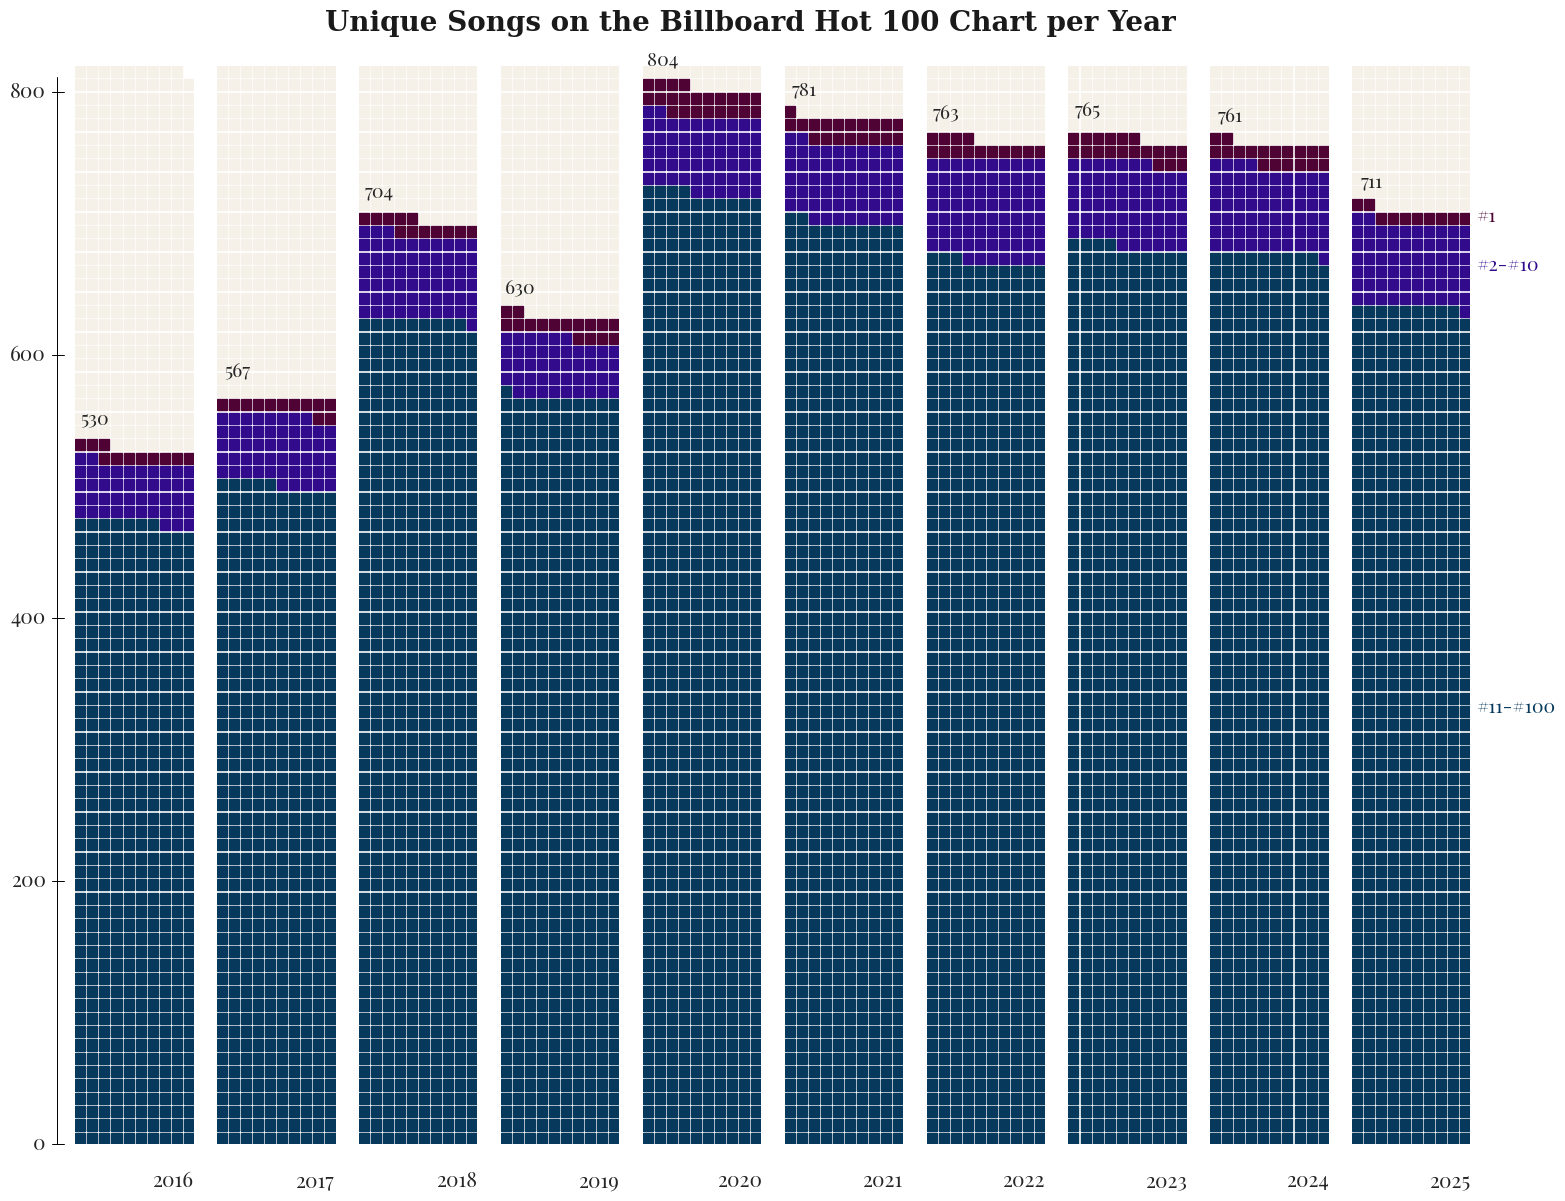

In [ ]:
# waffle chart 

max_year_value = 820

ncols = merged["year"].nunique()
fig, axs = plt.subplots(ncols=ncols, figsize=(18, 14))

# add y axis
y_ticks = [0, 200, 400, 600, 800]
for y_tick in y_ticks:
    axs[0].text(
        x=-0.25,
        y=y_tick / max_year_value,
        s=f"{y_tick}",
        size=15,
        va="center",
        ha="right",
        transform=axs[0].transAxes,
    )
    axs[0].axhline(
        y=y_tick / max_year_value,
        xmin=-0.2,
        xmax=-0.1,
        clip_on=False,
        color="black",
        linewidth=0.7,
    )
axs[0].axvline(x=-0.019, ymax=0.99, clip_on=False, color="black", linewidth=0.7)

# add waffle bars 
for year, ax in zip(np.sort(merged["year"].unique()), axs):
    row = merged.loc[merged["year"] == year].iloc[0]

    values = [
        row['num_1_count'],
        row['num_2_10_count'],
        row['num_11_100_count']
    ]

    values = sorted(values, reverse=True)
    values.append(max_year_value - sum(values))

    Waffle.make_waffle(
        ax=ax,
        rows=81,
        columns=10,
        values=values,
        vertical=True,
        colors=['#06395b', '#320b8d', '#4f0335', '#f5f0e8']
    )

    ax.text(x=0.1, y=-0.04, s=f"{int(year)}", fontsize=15, ha="center")
    adj_y = 0.02
    ax.text(
        x=0.02,
        y=sum(values[:-1]) / max_year_value + adj_y,
        s=f"{sum(values[:-1])}",
        fontsize=14,
        ha="center",
    )

# add labels 
label_params = dict(
    x=1.05,
    size=14,
    transform=axs[ncols - 1].transAxes,
    clip_on=False,
)
axs[ncols - 1].text(y=0.40, s="#11-#100", color='#06395b', **label_params)
axs[ncols - 1].text(y=0.81, s="#2-#10", color='#320b8d', **label_params)
axs[ncols - 1].text(y=0.855, s="#1", color='#4f0335', **label_params)

title_text = (
    "Unique Songs on the Billboard Hot 100 Chart per Year"
)
fig.suptitle(
    "Unique Songs on the Billboard Hot 100 Chart per Year",
    fontweight="bold",
    color="#1a1a1a",
    fontfamily="serif",
    y=0.92 # move title up/down
)

plt.show()


In [407]:
fig.savefig("../charts/waffle.svg", format="svg", bbox_inches="tight")

In [36]:
# num songs per year and num debuting at peak 
merged2 = pd.concat(
    [
        song_years.year.value_counts(),
        peak_debut_df.year.value_counts()
    ],
    axis=1
)

merged2.columns = ['total_songs', 'debut_at_peak']
merged2 = merged2.reset_index().rename(columns={'index': 'value'})
merged2['frac'] = merged2["debut_at_peak"]/merged2['total_songs']
merged2 = merged2.sort_values('year')

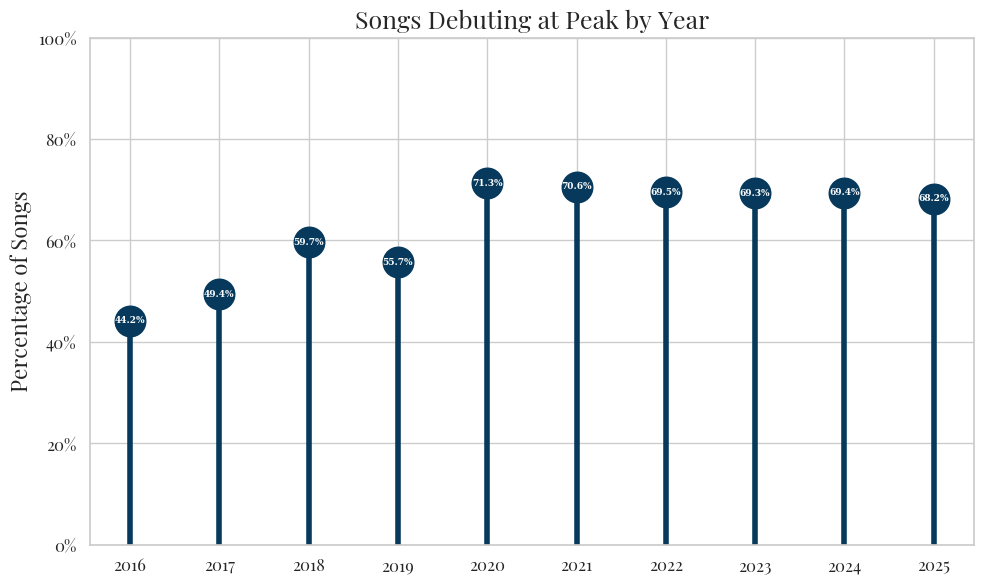

In [37]:
# percentage debuting at peak 

fig, ax = plt.subplots(figsize=(10, 6))

y = merged2["debut_at_peak"] / merged2["total_songs"] * 100
x = merged2["year"]

ax.vlines(x, 0, y, color='#06395b', lw=4)
ax.scatter(x, y, color='#06395b', s=400, linewidths=3)

for x_val, y_val in zip(x, y):
    ax.text(
        x_val,
        y_val - 0.5,
        f"{round(y_val,1)}%",
        color='white',
        ha='center',
        fontsize=6.5,
        font='serif',
        fontweight='bold'
    )

ax.set_xticks(x)
ax.set_xticklabels(x)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))

ax.set_ylabel("Percentage of Songs")
ax.set_title("Songs Debuting at Peak by Year", fontweight='bold')

plt.tight_layout()
plt.show()

In [38]:
fig.savefig("../charts/percentage_debut_at_peak.svg", format="svg", bbox_inches="tight")

## Stats

In [ ]:
# load data 
df = pd.read_csv("../data/clean_hot100_history.csv", low_memory=False)
df_song_rank = df.copy()
df_song_rank = (
    df_song_rank
    .sort_values('chart_date')
    .groupby(['title', 'artist'], as_index=False)
    .agg(
        weeks_in_data=('chart_date', 'count'),
        peak_position=('rank', 'min'),
        debut_rank=('rank', 'first')
    )
)

In [4]:
# number of artists 
df['artist_list'] = df['artist_list'].apply(ast.literal_eval)
df = df.explode('artist_list')
len(df.artist_list.unique())

1472

In [ ]:
# number of weeks 
len(df.chart_date.unique())

522

In [ ]:
# number of songs
len(df_song_rank.groupby(['title','artist'])['title'])

5869

In [ ]:
# summary of weeks in data
df_song_rank.weeks_in_data.describe()

count    5869.000000
mean        8.894190
std        11.427801
min         1.000000
25%         1.000000
50%         3.000000
75%        15.000000
max       112.000000
Name: weeks_in_data, dtype: float64

In [ ]:
# correlation of weeks to peak rank
df_song_rank["weeks_in_data"].corr(-df_song_rank["peak_position"]) # invert bc rankings are reversed 1-100

np.float64(0.5993477300307859)

In [ ]:
# correlation of debut to peak rank
df_song_rank["debut_rank"].corr(df_song_rank["peak_position"]) 

np.float64(0.7437611628308497)

In [ ]:
# stats for teddy swims / lose control infographic

# import data 
df = pd.read_csv("../data/filled_hot100_history.csv", low_memory=False)

# explode artists
df['artist_list'] = df['artist_list'].apply(ast.literal_eval)
df = df.explode('artist_list')

# filter 
sdf = df.loc[df['artist_list']=='Teddy Swims']

# num songs
print(sdf.title.unique())

# range of ranks 
print(sdf['rank'].describe())

# range of week lengths 
week_lengths = []
for title, group in sdf.groupby('title'):
    g = group.sort_values('chart_date').reset_index(drop=True)
    total_weeks = g['rank'].notna().sum()
    print(title, total_weeks)
    week_lengths.append(total_weeks)
print(pd.Series(week_lengths).describe())

# rise rate 
rise_df = pd.read_csv("../data/rise_rates.csv", low_memory=False)
rise_df['artist_list'] = rise_df['artist_list'].apply(ast.literal_eval)
rise_df = rise_df.explode('artist_list')
s_rise_df = rise_df.loc[rise_df['artist_list']=='Teddy Swims']
display(s_rise_df)

# decay rate 
decay_df = pd.read_csv("../data/decay_rates.csv", low_memory=False)
decay_df['artist_list'] = decay_df['artist_list'].apply(ast.literal_eval)
decay_df = decay_df.explode('artist_list')
s_decay_df = decay_df.loc[decay_df['artist_list']=='Teddy Swims']
display(s_decay_df)

display(sdf.drop_duplicates('title'))

<StringArray>
[           'Lose Control',                'The Door',
                   'Dirty',              'Bad Dreams',
       'Are You Even Real', 'Somethin' 'Bout A Woman',
          'Gone Gone Gone']
Length: 7, dtype: str
count    185.000000
mean      35.308108
std       31.098147
min        1.000000
25%        8.000000
50%       24.000000
75%       65.000000
max       99.000000
Name: rank, dtype: float64
Are You Even Real 14
Bad Dreams 24
Dirty 1
Gone Gone Gone 3
Lose Control 112
Somethin' 'Bout A Woman 6
The Door 25
count      7.000000
mean      26.428571
std       38.939514
min        1.000000
25%        4.500000
50%       14.000000
75%       24.500000
max      112.000000
dtype: float64


,artist,title,artist_list,total_weeks,peak_rank,debut_rank,peak_week,rise_rate
773,"David Guetta, Teddy Swims & Tones And I",Gone Gone Gone,Teddy Swims,3,91.0,92.0,1,1.000000
3298,Teddy Swims,Bad Dreams,Teddy Swims,24,30.0,75.0,31,1.451613
3299,Teddy Swims,Lose Control,Teddy Swims,112,1.0,99.0,31,3.161290
3300,Teddy Swims,The Door,Teddy Swims,25,24.0,94.0,17,4.117647
3301,Teddy Swims & GIVEON,Are You Even Real,Teddy Swims,14,59.0,59.0,0,0.000000
3411,Thomas Rhett Featuring Teddy Swims,Somethin' 'Bout A Woman,Teddy Swims,6,65.0,80.0,3,5.000000


,artist,title,artist_list,total_weeks,peak_rank,debut_rank,end_rank,peak_week,decay_rate,post_peak_length
773,"David Guetta, Teddy Swims & Tones And I",Gone Gone Gone,Teddy Swims,3,91.0,92.0,92.0,1,-1.000000,1
3298,Teddy Swims,Bad Dreams,Teddy Swims,24,30.0,75.0,41.0,31,-3.666667,3
3299,Teddy Swims,Lose Control,Teddy Swims,112,1.0,99.0,17.0,31,-0.197531,81
3300,Teddy Swims,The Door,Teddy Swims,25,24.0,94.0,33.0,17,-1.285714,7
3301,Teddy Swims & GIVEON,Are You Even Real,Teddy Swims,14,59.0,59.0,96.0,0,-2.176471,17
3411,Thomas Rhett Featuring Teddy Swims,Somethin' 'Bout A Woman,Teddy Swims,6,65.0,80.0,98.0,3,-16.500000,2


,chart_date,rank,title,artist,weeks_on_chart,peak_position,last_position,is_new,year,artist_list
62804,2023-08-26,99.0,Lose Control,Teddy Swims,1.0,99.0,0.0,True,2023.0,Teddy Swims
67905,2024-06-15,94.0,The Door,Teddy Swims,1.0,94.0,0.0,True,2024.0,Teddy Swims
68844,2024-08-17,79.0,Dirty,Jessie Murph With Teddy Swims,1.0,79.0,0.0,True,2024.0,Teddy Swims
69425,2024-09-28,75.0,Bad Dreams,Teddy Swims,1.0,75.0,0.0,True,2024.0,Teddy Swims
71302,2025-01-25,59.0,Are You Even Real,Teddy Swims & GIVEON,1.0,59.0,0.0,True,2025.0,Teddy Swims
72182,2025-04-05,80.0,Somethin' 'Bout A Woman,Thomas Rhett Featuring Teddy Swims,1.0,80.0,0.0,True,2025.0,Teddy Swims
74798,2025-12-13,92.0,Gone Gone Gone,"David Guetta, Teddy Swims & Tones And I",1.0,92.0,0.0,True,2025.0,Teddy Swims


In [40]:
# change in average weeks on chart for top 10 songs, first vs last year

# import data 
df = pd.read_csv("../data/filled_hot100_history.csv", low_memory=False)

# explode artists
df['artist_list'] = df['artist_list'].apply(ast.literal_eval)
df = df.explode('artist_list')

# get songs in top 10
top10 = df[df['rank'] <= 10].copy()

# group by and get number of weeks per year
weeks_by_year = (
    top10.groupby(['year', 'title', 'artist_list'])['chart_date']
    .count()
    .reset_index()
    .rename(columns={'chart_date': 'weeks'})
)

# average
avg_by_year = weeks_by_year.groupby('year')['weeks'].mean()
display(avg_by_year)
first_year = avg_by_year.index.min()
last_year  = avg_by_year.index.max()

pct_change = (avg_by_year[last_year] - avg_by_year[first_year]) / avg_by_year[first_year] * 100
print(f"Avg weeks on chart for top 10 songs: {avg_by_year[first_year]:.1f} ({first_year}) → {avg_by_year[last_year]:.1f} ({last_year})")
print(f"Change: {pct_change:+.1f}%")

year
2016.0    9.878049
2017.0    7.990909
2018.0    7.126050
2019.0    8.272727
2020.0    6.281250
2021.0    6.721739
2022.0    5.708029
2023.0    6.531532
2024.0    5.629310
2025.0    7.862745
Name: weeks, dtype: float64

Avg weeks on chart for top 10 songs: 9.9 (2016.0) → 7.9 (2025.0)
Change: -20.4%


In [ ]:
# change in average weeks on chart for all songs, first vs last year

# import data 
df = pd.read_csv("../data/filled_hot100_history.csv", low_memory=False)

# explode artists
df['artist_list'] = df['artist_list'].apply(ast.literal_eval)
df = df.explode('artist_list')

# group by and get number of weeks per year
weeks_by_year = (
    df.groupby(['year', 'title', 'artist_list'])['chart_date']
    .count()
    .reset_index()
    .rename(columns={'chart_date': 'weeks'})
)

# average
avg_by_year = weeks_by_year.groupby('year')['weeks'].mean()
display(avg_by_year)
first_year = avg_by_year.index.min()
last_year  = avg_by_year.index.max()

pct_change = (avg_by_year[last_year] - avg_by_year[first_year]) / avg_by_year[first_year] * 100
print(f"Avg weeks on chart for all songs: {avg_by_year[first_year]:.1f} ({first_year}) → {avg_by_year[last_year]:.1f} ({last_year})")
print(f"Change: {pct_change:+.1f}%")

year
2016.0    10.303235
2017.0     9.026316
2018.0     7.535747
2019.0     7.928862
2020.0     6.720034
2021.0     6.509275
2022.0     6.753764
2023.0     6.801668
2024.0     6.222420
2025.0     7.426531
Name: weeks, dtype: float64

Avg weeks on chart for all songs: 10.3 (2016.0) → 7.4 (2025.0)
Change: -27.9%


In [ ]:
# turnover at #1 -- how many unique songs hit #1 per year
number_ones = df[df['rank'] == 1].copy()

turnover_by_year = (
    number_ones.groupby('year')['title']
    .nunique()
    .reset_index()
    .rename(columns={'title': 'unique_number_ones'})
)
display(turnover_by_year)
first_turnover = turnover_by_year.loc[turnover_by_year['year'] == first_year, 'unique_number_ones'].values[0]
last_turnover  = turnover_by_year.loc[turnover_by_year['year'] == last_year,  'unique_number_ones'].values[0]

turnover_ratio = last_turnover / first_turnover
print(f"\nUnique #1 songs: {first_turnover} ({first_year}) → {last_turnover} ({last_year})")
print(f"Turnover ratio: {turnover_ratio:.1f}x")

,year,unique_number_ones
0,2016.0,11
1,2017.0,12
2,2018.0,12
3,2019.0,16
4,2020.0,22
5,2021.0,19
6,2022.0,14
7,2023.0,19
8,2024.0,18
9,2025.0,10



Unique #1 songs: 11 (2016.0) → 10 (2025.0)
Turnover ratio: 0.9x


In [50]:
# average weeks at #1
weeks_at_one = (
    number_ones.groupby(['year', 'title', 'artist'])['chart_date']
    .count()
    .reset_index()
    .rename(columns={'chart_date': 'weeks_at_one'})
)

avg_weeks_at_one = weeks_at_one.groupby('year')['weeks_at_one'].mean()
display(avg_weeks_at_one)
median_weeks_at_one = weeks_at_one.groupby('year')['weeks_at_one'].median()
max_weeks_at_one = weeks_at_one.groupby('year')['weeks_at_one'].max()
display(max_weeks_at_one)
min_weeks_at_one = weeks_at_one.groupby('year')['weeks_at_one'].min()
display(min_weeks_at_one)
range_weeks_at_one = weeks_at_one.groupby('year')['weeks_at_one'].agg(lambda x: x.max() - x.min())
print(f"\nAvg weeks at #1: {avg_weeks_at_one[first_year]:.1f} ({first_year}) → {avg_weeks_at_one[last_year]:.1f} ({last_year})")
print(f"\nMedian weeks at #1: {median_weeks_at_one[first_year]:.1f} ({first_year}) → {median_weeks_at_one[last_year]:.1f} ({last_year})")
print(f"\nMax weeks at #1: {max_weeks_at_one[first_year]:.1f} ({first_year}) → {max_weeks_at_one[last_year]:.1f} ({last_year})")
print(f"\nRange weeks at #1: {range_weeks_at_one[first_year]:.1f} ({first_year}) → {range_weeks_at_one[last_year]:.1f} ({last_year})")

year
2016.0    9.454545
2017.0    8.416667
2018.0    5.250000
2019.0    4.625000
2020.0    3.590909
2021.0    3.736842
2022.0    6.214286
2023.0    3.000000
2024.0    3.888889
2025.0    9.500000
Name: weeks_at_one, dtype: float64

year
2016.0    30
2017.0    48
2018.0    14
2019.0    38
2020.0    14
2021.0    14
2022.0    35
2023.0    16
2024.0    19
2025.0    32
Name: weeks_at_one, dtype: int64

year
2016.0    1
2017.0    1
2018.0    1
2019.0    1
2020.0    1
2021.0    1
2022.0    1
2023.0    1
2024.0    1
2025.0    1
Name: weeks_at_one, dtype: int64


Avg weeks at #1: 9.5 (2016.0) → 9.5 (2025.0)

Median weeks at #1: 3.0 (2016.0) → 6.0 (2025.0)

Max weeks at #1: 30.0 (2016.0) → 32.0 (2025.0)

Range weeks at #1: 29.0 (2016.0) → 31.0 (2025.0)


In [ ]:
# stats for bad bunny tab

# import data 
df = pd.read_csv("../data/filled_hot100_history.csv", low_memory=False)

# explode artists
df['artist_list'] = df['artist_list'].apply(ast.literal_eval)
df = df.explode('artist_list')

# filter 
sdf = df.loc[df['artist_list']=='Bad Bunny']

# num songs
print(sdf.title.unique())

# range of ranks 
print(sdf['rank'].describe())

# range of week lengths 
week_lengths = []
for title, group in sdf.groupby('title'):
    g = group.sort_values('chart_date').reset_index(drop=True)
    total_weeks = g['rank'].notna().sum()
    print(title, total_weeks)
    week_lengths.append(total_weeks)
print(pd.Series(week_lengths).describe())

# rise rate 
rise_df = pd.read_csv("../data/rise_rates.csv", low_memory=False)
rise_df['artist_list'] = rise_df['artist_list'].apply(ast.literal_eval)
rise_df = rise_df.explode('artist_list')
s_rise_df = rise_df.loc[rise_df['artist_list']=='Bad Bunny']
display(s_rise_df.sort_values('rise_rate', ascending=False).head(20))
display(s_rise_df.rise_rate.describe())

# decay rate 
decay_df = pd.read_csv("../data/decay_rates.csv", low_memory=False)
decay_df['artist_list'] = decay_df['artist_list'].apply(ast.literal_eval)
decay_df = decay_df.explode('artist_list')
s_decay_df = decay_df.loc[decay_df['artist_list']=='Bad Bunny']
display(s_decay_df.sort_values('decay_rate', ascending=False))

display(sdf.drop_duplicates('title'))

<StringArray>
[                'Mayores',             'Krippy Kush',
                 'El Bano',               'I Like It',
                 'Te Bote',                     'MIA',
              'Solo de Mi',                 'Soltera',
                'Callaita',           'Que Pretendes',
 ...
         'Perfumito Nuevo',                 'Weltita',
                     'EOO',              'Ketu Tecre',
               'Kloufrens',                  'Bokete',
                 'Turista',            'Cafe Con Ron',
 'Lo Que Le Paso A Hawaii',              'La Mudanza']
Length: 113, dtype: str
count    963.000000
mean      57.137072
std       28.089512
min        1.000000
25%       34.000000
50%       61.000000
75%       82.000000
max      100.000000
Name: rank, dtype: float64
AM 10
Acho PR 1
Adivino 2
Agosto 1
Aguacero 3
Andrea 4
Baby Nueva 2
Baile Inolvidable 20
Baticano 1
Bichiyal 1
Bokete 4
Booker T 1
Cafe Con Ron 4
Callaita 20
Coco Chanel 2
Cybertruck 2
DTMF 20
Dakiti 28
De Museo 1
Despue

,artist,title,artist_list,total_weeks,peak_rank,debut_rank,peak_week,rise_rate
236,Bad Bunny,La Mudanza,Bad Bunny,4,51.0,95.0,1,44.0
225,Bad Bunny,DTMF,Bad Bunny,20,2.0,38.0,1,36.0
266,Bad Bunny & Los Pleneros de La Cresta,Cafe Con Ron,Bad Bunny,4,48.0,83.0,1,35.0
237,Bad Bunny,Lo Que Le Paso A Hawaii,Bad Bunny,3,62.0,94.0,1,32.0
248,Bad Bunny,Turista,Bad Bunny,4,45.0,77.0,1,32.0
228,Bad Bunny,EOO,Bad Bunny,30,24.0,54.0,1,30.0
223,Bad Bunny,Bokete,Bad Bunny,4,42.0,69.0,1,27.0
234,Bad Bunny,Kloufrens,Bad Bunny,5,40.0,66.0,1,26.0
222,Bad Bunny,Baile Inolvidable,Bad Bunny,20,3.0,28.0,1,25.0
250,Bad Bunny,Un Preview,Bad Bunny,7,43.0,65.0,1,22.0


count    83.000000
mean      6.295155
std      11.020578
min       0.000000
25%       0.000000
50%       0.000000
75%       7.700000
max      44.000000
Name: rise_rate, dtype: float64

,artist,title,artist_list,total_weeks,peak_rank,debut_rank,end_rank,peak_week,decay_rate,post_peak_length
229,Bad Bunny,Efecto,Bad Bunny,22,34.0,34.0,49.0,0,-0.714286,21
546,"Casper Magico, Nio Garcia, Darell, Nicky Jam, ...",Te Bote,Bad Bunny,21,36.0,74.0,50.0,5,-0.933333,15
522,"Cardi B, Bad Bunny & J Balvin",I Like It,Bad Bunny,51,1.0,8.0,45.0,11,-1.128205,39
247,Bad Bunny,Titi Me Pregunto,Bad Bunny,30,5.0,5.0,44.0,0,-1.344828,29
269,Bad Bunny & ROSALIA,La Noche de Anoche,Bad Bunny,17,53.0,53.0,88.0,0,-1.458333,24
...,...,...,...,...,...,...,...,...,...,...
241,Bad Bunny,Mr. October,Bad Bunny,2,28.0,28.0,73.0,0,-45.000000,1
268,Bad Bunny & Mora,Hibiki,Bad Bunny,2,24.0,24.0,72.0,0,-48.000000,1
224,Bad Bunny,Cybertruck,Bad Bunny,2,30.0,30.0,82.0,0,-52.000000,1
259,Bad Bunny & Bryant Myers,Seda,Bad Bunny,2,38.0,38.0,90.0,0,-52.000000,1


,chart_date,rank,title,artist,weeks_on_chart,peak_position,last_position,is_new,year,artist_list
17376,2017-11-04,97.0,Mayores,Becky G Featuring Bad Bunny,1.0,97.0,0.0,True,2017.0,Bad Bunny
17921,2017-12-16,86.0,Krippy Kush,"Farruko, Nicki Minaj, Bad Bunny, 21 Savage & R...",1.0,86.0,0.0,True,2017.0,Bad Bunny
18814,2018-01-27,98.0,El Bano,Enrique Iglesias Featuring Bad Bunny,1.0,98.0,0.0,True,2018.0,Bad Bunny
20158,2018-04-21,8.0,I Like It,"Cardi B, Bad Bunny & J Balvin",1.0,8.0,0.0,True,2018.0,Bad Bunny
20500,2018-05-05,74.0,Te Bote,"Casper Magico, Nio Garcia, Darell, Nicky Jam, ...",1.0,74.0,0.0,True,2018.0,Bad Bunny
...,...,...,...,...,...,...,...,...,...,...
71259,2025-01-18,69.0,Bokete,Bad Bunny,1.0,69.0,0.0,True,2025.0,Bad Bunny
71285,2025-01-18,77.0,Turista,Bad Bunny,1.0,77.0,0.0,True,2025.0,Bad Bunny
71289,2025-01-18,83.0,Cafe Con Ron,Bad Bunny & Los Pleneros de La Cresta,1.0,83.0,0.0,True,2025.0,Bad Bunny
71294,2025-01-18,94.0,Lo Que Le Paso A Hawaii,Bad Bunny,1.0,94.0,0.0,True,2025.0,Bad Bunny


In [ ]:
# stats for shawn mendes tab

# import data 
df = pd.read_csv("../data/filled_hot100_history.csv", low_memory=False)

# explode artists
df['artist_list'] = df['artist_list'].apply(ast.literal_eval)
df = df.explode('artist_list')

# filter 
sdf = df.loc[df['artist_list']=='Shawn Mendes']

# num songs
# print(sdf.title.unique())

# range of ranks 
print(sdf['rank'].describe())

# range of week lengths 
week_lengths = []
for title, group in sdf.groupby('title'):
    g = group.sort_values('chart_date').reset_index(drop=True)
    total_weeks = g['rank'].notna().sum()
    # print(title, total_weeks)
    week_lengths.append(total_weeks)
print(pd.Series(week_lengths).describe())

# rise rate 
rise_df = pd.read_csv("../data/rise_rates.csv", low_memory=False)
rise_df['artist_list'] = rise_df['artist_list'].apply(ast.literal_eval)
rise_df = rise_df.explode('artist_list')
s_rise_df = rise_df.loc[rise_df['artist_list']=='Shawn Mendes']
display(s_rise_df.sort_values('rise_rate', ascending=False).head(20))
display(s_rise_df.rise_rate.describe())

# decay rate 
decay_df = pd.read_csv("../data/decay_rates.csv", low_memory=False)
decay_df['artist_list'] = decay_df['artist_list'].apply(ast.literal_eval)
decay_df = decay_df.explode('artist_list')
s_decay_df = decay_df.loc[decay_df['artist_list']=='Shawn Mendes']
display(s_decay_df.sort_values('decay_rate', ascending=False).head(20))
display(s_decay_df.decay_rate.describe())

display(sdf.drop_duplicates('title'))

count    294.000000
mean      33.636054
std       25.242446
min        1.000000
25%       14.000000
50%       26.000000
75%       48.000000
max       99.000000
Name: rank, dtype: float64
count    15.000000
mean     19.600000
std      12.004761
min       1.000000
25%      12.500000
50%      16.000000
75%      27.500000
max      39.000000
dtype: float64


,artist,title,artist_list,total_weeks,peak_rank,debut_rank,peak_week,rise_rate
3085,Shawn Mendes & Camila Cabello,I Know What You Did Last Summer,Shawn Mendes,16,20.0,46.0,4,6.500000
3078,Shawn Mendes,In My Blood,Shawn Mendes,23,11.0,72.0,10,6.100000
3079,Shawn Mendes,Mercy,Shawn Mendes,32,15.0,95.0,28,2.857143
3081,Shawn Mendes,There's Nothing Holdin' Me Back,Shawn Mendes,34,6.0,44.0,15,2.533333
3082,Shawn Mendes,Treat You Better,Shawn Mendes,39,6.0,34.0,15,1.866667
3080,Shawn Mendes,Stitches,Shawn Mendes,23,6.0,9.0,2,1.500000
3090,Shawn Mendes X Zedd,Lost In Japan,Shawn Mendes,16,48.0,64.0,31,0.516129
3086,Shawn Mendes & Camila Cabello,Senorita,Shawn Mendes,37,1.0,2.0,8,0.125000
3077,Shawn Mendes,If I Can't Have You,Shawn Mendes,23,2.0,2.0,0,0.000000
3084,Shawn Mendes,Wonder,Shawn Mendes,11,18.0,18.0,0,0.000000


count    14.000000
mean      1.571305
std       2.244506
min       0.000000
25%       0.000000
50%       0.320565
75%       2.366667
max       6.500000
Name: rise_rate, dtype: float64

,artist,title,artist_list,total_weeks,peak_rank,debut_rank,end_rank,peak_week,decay_rate,post_peak_length
3086,Shawn Mendes & Camila Cabello,Senorita,Shawn Mendes,37,1.0,2.0,43.0,8,-1.500000,28
3082,Shawn Mendes,Treat You Better,Shawn Mendes,39,6.0,34.0,45.0,15,-1.695652,23
3080,Shawn Mendes,Stitches,Shawn Mendes,23,6.0,9.0,41.0,2,-1.750000,20
3077,Shawn Mendes,If I Can't Have You,Shawn Mendes,23,2.0,2.0,48.0,0,-2.090909,22
3083,Shawn Mendes,When You're Gone,Shawn Mendes,15,38.0,38.0,70.0,0,-2.285714,14
3081,Shawn Mendes,There's Nothing Holdin' Me Back,Shawn Mendes,34,6.0,44.0,48.0,15,-2.333333,18
3078,Shawn Mendes,In My Blood,Shawn Mendes,23,11.0,72.0,42.0,10,-2.583333,12
3090,Shawn Mendes X Zedd,Lost In Japan,Shawn Mendes,16,48.0,64.0,84.0,31,-3.600000,10
3089,Shawn Mendes Featuring Khalid,Youth,Shawn Mendes,2,65.0,65.0,76.0,0,-3.666667,3
3079,Shawn Mendes,Mercy,Shawn Mendes,32,15.0,95.0,48.0,28,-4.714286,7


count    14.000000
mean     -3.564372
std       1.809699
min      -6.923077
25%      -5.035714
50%      -3.091667
75%      -2.139610
max      -1.500000
Name: decay_rate, dtype: float64

,chart_date,rank,title,artist,weeks_on_chart,peak_position,last_position,is_new,year,artist_list
173,2016-01-02,9.0,Stitches,Shawn Mendes,30.0,4.0,7.0,False,2016.0,Shawn Mendes
2147,2016-01-02,46.0,I Know What You Did Last Summer,Shawn Mendes & Camila Cabello,5.0,46.0,52.0,False,2016.0,Shawn Mendes
6761,2016-06-25,34.0,Treat You Better,Shawn Mendes,1.0,34.0,0.0,True,2016.0,Shawn Mendes
7751,2016-09-10,95.0,Mercy,Shawn Mendes,1.0,95.0,0.0,True,2016.0,Shawn Mendes
14611,2017-05-13,44.0,There's Nothing Holdin' Me Back,Shawn Mendes,1.0,44.0,0.0,True,2017.0,Shawn Mendes
19800,2018-03-31,72.0,In My Blood,Shawn Mendes,1.0,72.0,0.0,True,2018.0,Shawn Mendes
19895,2018-04-07,64.0,Lost In Japan,Shawn Mendes X Zedd,1.0,64.0,0.0,True,2018.0,Shawn Mendes
20744,2018-05-19,65.0,Youth,Shawn Mendes Featuring Khalid,1.0,65.0,0.0,True,2018.0,Shawn Mendes
31893,2019-05-18,2.0,If I Can't Have You,Shawn Mendes,1.0,2.0,0.0,True,2019.0,Shawn Mendes
32837,2019-07-06,2.0,Senorita,Shawn Mendes & Camila Cabello,1.0,2.0,0.0,True,2019.0,Shawn Mendes


In [5]:
# stats for luke combs tab 

# import data 
df = pd.read_csv("../data/filled_hot100_history.csv", low_memory=False)

# explode artists
df['artist_list'] = df['artist_list'].apply(ast.literal_eval)
df = df.explode('artist_list')

# filter 
sdf = df.loc[df['artist_list']=='Luke Combs']

# num songs
print(len(sdf.title.unique()))

# range of ranks 
print(sdf['rank'].describe())

# range of week lengths 
week_lengths = []
for title, group in sdf.groupby('title'):
    g = group.sort_values('chart_date').reset_index(drop=True)
    total_weeks = g['rank'].notna().sum()
    # print(title, total_weeks)
    week_lengths.append(total_weeks)
print(pd.Series(week_lengths).describe())

# rise rate 
rise_df = pd.read_csv("../data/rise_rates.csv", low_memory=False)
rise_df['artist_list'] = rise_df['artist_list'].apply(ast.literal_eval)
rise_df = rise_df.explode('artist_list')
s_rise_df = rise_df.loc[rise_df['artist_list']=='Luke Combs']
display(s_rise_df.sort_values('rise_rate', ascending=False).head(20))
display(s_rise_df.rise_rate.describe())

# decay rate 
decay_df = pd.read_csv("../data/decay_rates.csv", low_memory=False)
decay_df['artist_list'] = decay_df['artist_list'].apply(ast.literal_eval)
decay_df = decay_df.explode('artist_list')
s_decay_df = decay_df.loc[decay_df['artist_list']=='Luke Combs']
display(s_decay_df.sort_values('decay_rate', ascending=False).head(20))
display(s_decay_df.decay_rate.describe())

display(sdf.drop_duplicates('title'))

39
count    643.000000
mean      45.163297
std       23.758581
min        2.000000
25%       27.500000
50%       42.000000
75%       61.000000
max      100.000000
Name: rank, dtype: float64
count    39.000000
mean     16.487179
std      13.216560
min       1.000000
25%       3.000000
50%      20.000000
75%      23.000000
max      56.000000
dtype: float64


,artist,title,artist_list,total_weeks,peak_rank,debut_rank,peak_week,rise_rate
2175,Luke Combs,The Man He Sees In Me,Luke Combs,3,39.0,58.0,1,19.000000
2153,Luke Combs,5 Leaf Clover,Luke Combs,7,33.0,45.0,1,12.000000
2169,Luke Combs,Lovin' On You,Luke Combs,20,23.0,93.0,10,7.000000
2180,Luke Combs Featuring Eric Church,Does To Me,Luke Combs,19,20.0,86.0,10,6.600000
2165,Luke Combs,"Going, Going, Gone",Luke Combs,22,23.0,99.0,12,6.333333
1482,Jameson Rodgers Featuring Luke Combs,Cold Beer Calling My Name,Luke Combs,19,26.0,95.0,12,5.750000
2167,Luke Combs,Hurricane,Luke Combs,22,31.0,96.0,12,5.416667
2178,Luke Combs,Where The Wild Things Are,Luke Combs,22,26.0,84.0,11,5.272727
2170,Luke Combs,One Number Away,Luke Combs,20,34.0,84.0,10,5.000000
2177,Luke Combs,When It Rains It Pours,Luke Combs,20,33.0,85.0,11,4.727273


count    33.000000
mean      3.268854
std       4.022330
min       0.000000
25%       0.375000
50%       1.250000
75%       5.000000
max      19.000000
Name: rise_rate, dtype: float64

,artist,title,artist_list,total_weeks,peak_rank,debut_rank,end_rank,peak_week,decay_rate,post_peak_length
2178,Luke Combs,Where The Wild Things Are,Luke Combs,22,26.0,84.0,29.0,11,-0.300000,10
2163,Luke Combs,Fast Car,Luke Combs,56,2.0,44.0,18.0,12,-0.372093,43
2176,Luke Combs,Tomorrow Me,Luke Combs,4,61.0,61.0,66.0,0,-0.555556,9
2168,Luke Combs,Love You Anyway,Luke Combs,33,15.0,15.0,43.0,0,-0.875000,32
2164,Luke Combs,Forever After All,Luke Combs,45,2.0,2.0,41.0,0,-0.886364,44
2174,Luke Combs,The Kind Of Love We Make,Luke Combs,32,8.0,18.0,36.0,13,-1.217391,23
2160,Luke Combs,Days Like These,Luke Combs,8,79.0,93.0,87.0,3,-1.333333,6
2154,Luke Combs,Ain't No Love In Oklahoma,Luke Combs,27,13.0,23.0,38.0,9,-1.470588,17
2179,Luke Combs Featuring Amanda Shires,Without You,Luke Combs,2,70.0,70.0,78.0,0,-1.600000,5
2170,Luke Combs,One Number Away,Luke Combs,20,34.0,84.0,49.0,10,-1.666667,9


count    33.000000
mean     -8.855096
std      12.649104
min     -57.000000
25%     -10.000000
50%      -3.111111
75%      -1.600000
max      -0.300000
Name: decay_rate, dtype: float64

,chart_date,rank,title,artist,weeks_on_chart,peak_position,last_position,is_new,year,artist_list
13139,2017-03-04,96.0,Hurricane,Luke Combs,1.0,96.0,0.0,True,2017.0,Luke Combs
16025,2017-08-19,85.0,When It Rains It Pours,Luke Combs,1.0,85.0,0.0,True,2017.0,Luke Combs
19839,2018-03-31,84.0,One Number Away,Luke Combs,1.0,84.0,0.0,True,2018.0,Luke Combs
20686,2018-05-19,58.0,Beautiful Crazy,Luke Combs,1.0,58.0,0.0,True,2018.0,Luke Combs
21303,2018-06-16,81.0,Must've Never Met You,Luke Combs,1.0,81.0,0.0,True,2018.0,Luke Combs
22572,2018-08-25,95.0,She Got The Best Of Me,Luke Combs,1.0,95.0,0.0,True,2018.0,Luke Combs
31967,2019-05-18,68.0,Beer Never Broke My Heart,Luke Combs,1.0,68.0,0.0,True,2019.0,Luke Combs
32615,2019-06-22,62.0,Even Though I'm Leaving,Luke Combs,1.0,62.0,0.0,True,2019.0,Luke Combs
34590,2019-09-28,97.0,"1, 2 Many",Luke Combs & Brooks & Dunn,1.0,97.0,0.0,True,2019.0,Luke Combs
35340,2019-11-23,72.0,Better Together,Luke Combs,1.0,72.0,0.0,True,2019.0,Luke Combs
